In [12]:
import numpy as np
import numpy.fft as fft   # η βιβλιοθήκη FFT του NumPy
import matplotlib.pyplot as plt

## Άσκηση - Προσομοίωση του DTFT μέσω του FFT

Στην άσκηση $\texttt{Ex-DTFT}$ υπολογίσαμε τον μετασχ. Fourier διακριτού χρόνου (DTFT) «με το χέρι», αθροίζοντας ρητά μιγαδικά εκθετικά πάνω σε ένα πλέγμα συχνοτήτων $\omega_k \in (-\pi, \pi]$. Ο τρόπος αυτός είναι διαφανής και διδακτικός, αλλά υπολογιστικά ακριβός: για $N$ δείγματα στο χρόνο και $M$ συχνότητες κοστίζει $\mathcal{O}(NM)$ πράξεις.

Σε αυτήν την άσκηση θα δούμε ότι υπάρχει ένα $\textit{θεμελιώδες}$ και πανίσχυρο εργαλείο που μας δίνει σχεδόν $\textbf{δωρεάν}$ δείγματα του DTFT: ο $\textbf{γρήγορος μετασχ. Fourier (FFT)}$. Θα κατανοήσουμε ακριβώς $\textit{ποια}$ σχέση συνδέει τον (συνεχή) DTFT με τον (διακριτό) DFT που υπολογίζει ο FFT, και θα δούμε πώς, με τη σωστή χρήση του `numpy.fft`, μπορούμε να «προσομοιώσουμε» τον DTFT με ελάχιστο κώδικα και σε χρόνο $\mathcal{O}(M\log M)$. 😃 Όπως και πριν, ο κώδικας είναι λίγος — το ζητούμενο είναι η κατανόηση.

### Υπενθύμιση: DTFT και DFT

Ας ξεκινήσουμε θυμίζοντας τον ορισμό του DTFT ενός σήματος $x[n]$:

\begin{equation}
X(e^{j\omega}) = \sum_{n=-\infty}^{+\infty} x[n]\, e^{-j\omega n}
\end{equation}

Ο DTFT είναι $\textit{συνεχής}$ και $2\pi$-περιοδική συνάρτηση της συχνότητας $\omega$. Στον υπολογιστή δεν μπορούμε να τον αναπαραστήσουμε παρά μόνο σε $\textit{πεπερασμένο}$ πλήθος συχνοτήτων — αυτό ακριβώς κάναμε στην προηγούμενη άσκηση.

Θεωρήστε τώρα ένα σήμα $\textbf{πεπερασμένης διάρκειας}$ $N$, με μη μηδενικά δείγματα $x[0], x[1], \dots, x[N-1]$. Ο $\textbf{διακριτός μετασχ. Fourier (DFT)}$ $N$ σημείων του ορίζεται ως

\begin{equation}
X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j\frac{2\pi}{N} k n}, \qquad k = 0, 1, \dots, N-1.
\end{equation}

Ο $\textbf{FFT}$ (Fast Fourier Transform) $\textit{δεν}$ είναι ένας διαφορετικός μετασχηματισμός: είναι απλώς ένας $\textbf{γρήγορος αλγόριθμος}$ που υπολογίζει $\textit{ακριβώς}$ αυτό το άθροισμα $X[k]$ σε $\mathcal{O}(N\log N)$ πράξεις αντί για $\mathcal{O}(N^2)$.

### Η κρίσιμη σχέση: ο DFT δειγματοληπτεί τον DTFT

Συγκρίνετε προσεκτικά τους δύο ορισμούς. Για το ίδιο σήμα πεπερασμένης διάρκειας $N$, ο DTFT γράφεται

\begin{equation}
X(e^{j\omega}) = \sum_{n=0}^{N-1} x[n]\, e^{-j\omega n},
\end{equation}

ενώ ο DFT είναι το $\textit{ίδιο ακριβώς}$ άθροισμα, υπολογισμένο μόνο στις $\textit{συγκεκριμένες}$ συχνότητες $\omega = \frac{2\pi}{N} k$. Δηλαδή

\begin{equation}
\boxed{\; X[k] = X\!\left(e^{j\omega}\right)\Big|_{\omega = \frac{2\pi}{N} k} = X\!\left(e^{j\frac{2\pi}{N} k}\right) \;}
\end{equation}

Με λόγια: $\textbf{ο } N\textbf{-σημειακός DFT ενός σήματος πεπερασμένης διάρκειας }N \textbf{ είναι ακριβώς ο DTFT του, δειγματοληπτημένος σε } N \textbf{ ισαπέχουσες συχνότητες}$ στο διάστημα $[0, 2\pi)$, με βήμα $\Delta\omega = \frac{2\pi}{N}$.

Αυτή είναι η γέφυρα μεταξύ των δύο κόσμων. Ο FFT δεν μας δίνει «κάτι σαν» τον DTFT — μας δίνει $\textit{ακριβή}$ δείγματά του (μέχρι το σφάλμα στρογγυλοποίησης), αρκεί το σήμα να έχει $\textbf{πραγματικά}$ πεπερασμένη διάρκεια εντός των $N$ δειγμάτων.

### Άξονας συχνοτήτων: μηδενική συμπλήρωση (zero-padding)

Ο $N$-σημείων FFT μάς δίνει μόνο $N$ δείγματα του DTFT — ένα αρκετά «αραιό» πλέγμα αν το $N$ είναι μικρό. Πώς παίρνουμε $\textit{περισσότερα}$ δείγματα της $\textit{ίδιας}$ συνεχούς καμπύλης $X(e^{j\omega})$;

Η απάντηση είναι η $\textbf{μηδενική συμπλήρωση}$: προσαρτούμε μηδενικά στο τέλος του σήματος ώστε το μήκος του να γίνει $M > N$, και υπολογίζουμε τον $M$-σημειακό FFT. Επειδή τα μηδενικά $\textit{δεν αλλάζουν}$ το άθροισμα του DTFT

\begin{equation}
\sum_{n=0}^{M-1} x[n] e^{-j\omega n} = \sum_{n=0}^{N-1} x[n] e^{-j\omega n} \quad (\text{αφού } x[n]=0 \text{ για } n \ge N),
\end{equation}

ο $M$-σημείων DFT δειγματοληπτεί την $\textbf{ίδια}$ συνάρτηση DTFT, απλώς σε ένα $\textbf{πυκνότερο}$ πλέγμα $\omega_k = \frac{2\pi}{M} k$, $k=0,\dots,M-1$.

$\textbf{Προσοχή στην παρανόηση:}$ η μηδενική συμπλήρωση $\textit{δεν προσθέτει πληροφορία}$ και $\textit{δεν βελτιώνει}$ τη φασματική διακριτική ικανότητα — αυτή καθορίζεται από την πραγματική διάρκεια $N$ του σήματος. Απλώς μας δίνει μια $\textbf{πυκνότερη παρεμβολή}$ (interpolation) της ήδη υπάρχουσας καμπύλης DTFT, κάτι που είναι χρήσιμο για να τη σχεδιάσουμε ομαλά. Μαθηματικά, τα δείγματα του $N$-σημειακού DFT συνδέονται με τον συνεχή DTFT μέσω παρεμβολής τύπου Dirichlet (περιοδικό sinc).

### Τάξη συχνοτήτων και κεντράρισμα: `fftfreq` και `fftshift`

Ο `numpy.fft.fft` επιστρέφει τα δείγματα $X[k]$ με τη «φυσική» τάξη του DFT: οι δείκτες $k=0,1,\dots,M-1$ αντιστοιχούν στις συχνότητες

\begin{equation}
\omega_k = \frac{2\pi k}{M}, \qquad k = 0,\dots,M-1,
\end{equation}

δηλαδή καλύπτουν το διάστημα $[0, 2\pi)$. Λόγω της $2\pi$-περιοδικότητας του DTFT, οι συχνότητες στο $[\pi, 2\pi)$ είναι ισοδύναμες με αυτές στο $[-\pi, 0)$. Για να τυπώσουμε το φάσμα με τον συνηθισμένο τρόπο, δηλ. κεντραρισμένο γύρω από το $\omega=0$ στο διάστημα $[-\pi, \pi)$, χρησιμοποιούμε δύο βοηθητικές συναρτήσεις:

* `numpy.fft.fftfreq(M)` → επιστρέφει τις συχνότητες σε $\textit{κύκλους ανά δείγμα}$· πολλαπλασιάζοντας επί $2\pi$ παίρνουμε ακτίνια/δείγμα.
* `numpy.fft.fftshift(...)` → αναδιατάσσει το διάνυσμα ώστε η μηδενική συχνότητα να βρεθεί στο κέντρο, δίνοντας μονότονο άξονα από $-\pi$ έως (σχεδόν) $+\pi$.

Έτσι το πλέγμα που προκύπτει είναι το $\{-\pi, -\pi+\Delta\omega, \dots, \pi-\Delta\omega\}$ με $\Delta\omega = 2\pi/M$ (το άκρο $-\pi$ περιλαμβάνεται, το $+\pi$ όχι — αλλά λόγω περιοδικότητας $X(e^{-j\pi}) = X(e^{j\pi})$).

### Αρχή του χρόνου: διόρθωση γραμμικής φάσης

Ο DFT «υποθέτει» πάντα ότι το πρώτο δείγμα του διανύσματος αντιστοιχεί σε $n=0$. Αν όμως το σήμα μας ξεκινά σε κάποιο $n_0 \neq 0$ (π.χ. ένα αιτιατό σήμα που αποθηκεύουμε από $n=-N$), πρέπει να το λάβουμε υπόψη. Από τον ορισμό, αν μετατοπίσουμε τη μεταβλητή $m = n - n_0$:

\begin{equation}
X(e^{j\omega}) = \sum_{n} x[n] e^{-j\omega n} = e^{-j\omega n_0} \sum_{m} \tilde{x}[m] e^{-j\omega m},
\end{equation}

όπου το δεύτερο άθροισμα είναι αυτό που υπολογίζει ο FFT (θεωρώντας το πρώτο δείγμα στο $m=0$). Επομένως αρκεί να πολλαπλασιάσουμε το αποτέλεσμα του FFT με τον $\textbf{παράγοντα γραμμικής φάσης}$ $e^{-j\omega n_0}$ για να πάρουμε τον σωστό DTFT ως προς την πραγματική αρχή του χρόνου. Αυτό ακριβώς κάνει η παρακάτω συνάρτηση.

In [13]:
def myDTFTviaFFT(x, n, Nfft=None):
    """
    Υπολογίζει (δείγματα του) DTFT ενός σήματος διακριτού χρόνου μέσω FFT.

    Ορίσματα:
        x    : 1D πίνακας, τα δείγματα του σήματος (μήκος N)
        n    : 1D πίνακας, οι αντίστοιχοι (συνεχόμενοι) χρονικοί δείκτες (μήκος N)
        Nfft : (προαιρετικό) μήκος του FFT. Αν Nfft > N γίνεται μηδενική
               συμπλήρωση (zero-padding) -> πυκνότερη δειγματοληψία του DTFT.

    Επιστρέφει:
        X : 1D μιγαδικός πίνακας μήκους Nfft (δείγματα DTFT, κεντραρισμένα)
        w : 1D πραγματικός πίνακας μήκους Nfft (πλέγμα συχνοτήτων, ακτίνια/δείγμα)
    """
    x = np.asarray(x, dtype=np.complex128)
    n = np.asarray(n)
    N = len(x)

    if Nfft is None:
        Nfft = N
    if Nfft < N:
        raise ValueError("Nfft must be >= len(x)")

    n0 = int(n[0])                          # αρχή του χρόνου (υποθέτουμε βήμα 1)

    # 1) FFT: υπολογίζει το DTFT στις συχνότητες 2*pi*k/Nfft (με zero-padding)
    Xnat = np.fft.fft(x, Nfft)              # φυσική τάξη [0, 2*pi)

    # 2) Πλέγμα συχνοτήτων σε ακτίνια/δείγμα και κεντράρισμα στο [-pi, pi)
    w = 2 * np.pi * np.fft.fftfreq(Nfft)
    w = np.fft.fftshift(w)
    X = np.fft.fftshift(Xnat)

    # 3) Διόρθωση γραμμικής φάσης για την πραγματική αρχή του χρόνου n0
    X = X * np.exp(-1j * w * n0)

    return X, w

### Επεξήγηση:

Η συνάρτηση συμπυκνώνει όσα είπαμε στη θεωρία. Ο πυρήνας είναι μία μόνο γραμμή, η `np.fft.fft(x, Nfft)`, η οποία με το όρισμα `Nfft` κάνει $\textit{αυτόματα}$ τη μηδενική συμπλήρωση και υπολογίζει τον DTFT στο πυκνό πλέγμα $\omega_k = 2\pi k/\texttt{Nfft}$. Οι `fftfreq` και `fftshift` απλώς κατασκευάζουν και κεντράρουν τον άξονα συχνοτήτων, ενώ ο παράγοντας $e^{-j\omega n_0}$ διορθώνει την αρχή του χρόνου. Συγκρίνετε με την `myDTFT` της προηγούμενης άσκησης: εκεί το κόστος ήταν $\mathcal{O}(NM)$ λόγω του πολλαπλασιασμού πινάκων· εδώ είναι $\mathcal{O}(M\log M)$ χάρη στον FFT — τεράστια διαφορά για μεγάλα $M$.

---

Ας ελέγξουμε τη συνάρτηση στο γνωστό σήμα
\begin{equation}
x[n] = (1/2)^n u[n],
\end{equation}
του οποίου ο DTFT είναι αναλυτικά
\begin{equation}
X(e^{j\omega}) = \frac{1}{1 - \tfrac{1}{2} e^{-j\omega}}.
\end{equation}
Θα υπερθέσουμε στο ίδιο διάγραμμα τα δείγματα που δίνει ο FFT (κουκκίδες) και την αναλυτική καμπύλη (συνεχής γραμμή), για να δούμε ότι $\textit{ταυτίζονται}$.

Μέγιστο απόλυτο σφάλμα: 7.021666937153402e-16


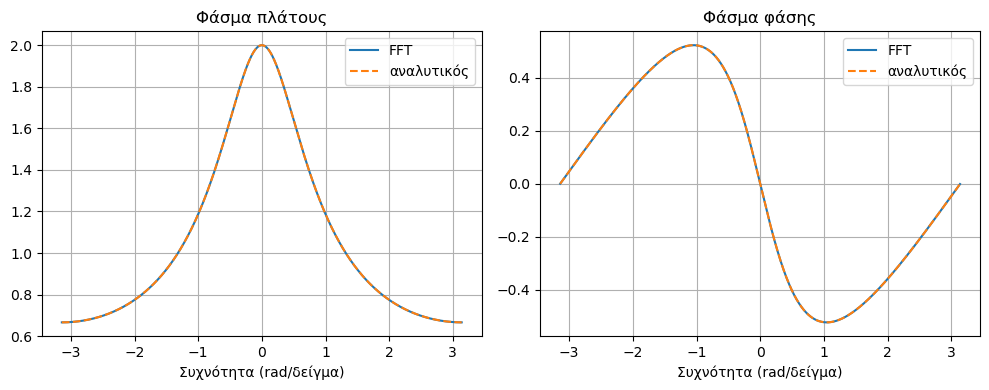

In [14]:
# Έλεγχος της myDTFTviaFFT έναντι του αναλυτικού DTFT
N = 64                       # (πεπερασμένη) διάρκεια σήματος - το (1/2)^n έχει ήδη σβήσει
n = np.arange(N)             # χρόνος 0..N-1
x = (1/2)**n                 # σήμα: (1/2)^n u[n]

Nfft = 2048                  # μηδενική συμπλήρωση -> πυκνή, ομαλή καμπύλη
X, w = myDTFTviaFFT(x, n, Nfft)

Xan = 1.0 / (1 - 0.5*np.exp(-1j*w))   # αναλυτικός DTFT για σύγκριση

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X), label="FFT")
plt.plot(w, np.abs(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend()
plt.title("Φάσμα πλάτους")
plt.xlabel("Συχνότητα (rad/δείγμα)")

plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X), label="FFT")
plt.plot(w, np.angle(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend()
plt.title("Φάσμα φάσης")
plt.xlabel("Συχνότητα (rad/δείγμα)")

plt.tight_layout()

print("Μέγιστο απόλυτο σφάλμα:", np.max(np.abs(X - Xan)))

Οι δύο καμπύλες πέφτουν η μία πάνω στην άλλη και το σφάλμα είναι της τάξης του σφάλματος στρογγυλοποίησης ($\sim 10^{-15}$). Ο FFT πράγματι μας έδωσε τον DTFT.

---

### Οπτική απόδειξη: ο FFT «πέφτει» πάνω στην καμπύλη του DTFT

Για να δούμε ξεκάθαρα ότι $\textit{ο DFT δειγματοληπτεί τον DTFT}$ και ότι η $\textit{μηδενική συμπλήρωση απλώς πυκνώνει}$ αυτά τα δείγματα, ας πάρουμε έναν $\textbf{ορθογώνιο παλμό}$ μήκους $L$,
\begin{equation}
x[n] = \begin{cases} 1, & 0 \le n \le L-1 \\ 0, & \text{αλλού} \end{cases}
\end{equation}
του οποίου ο DTFT είναι ο γνωστός πυρήνας Dirichlet
\begin{equation}
X(e^{j\omega}) = e^{-j\omega (L-1)/2}\, \frac{\sin(\omega L/2)}{\sin(\omega/2)}.
\end{equation}
Θα σχεδιάσουμε: 

- (α) τον «αραιό» $L$-σημειακό FFT (κόκκινες κουκκίδες), 

- (β) τον «πυκνό» FFT με μηδενική συμπλήρωση (μπλε κουκκίδες), και 

- (γ) τη συνεχή αναλυτική καμπύλη DTFT (γκρι γραμμή). 

Παρατηρήστε ότι $\textbf{όλες}$ οι κουκκίδες πέφτουν πάνω στην ίδια καμπύλη.

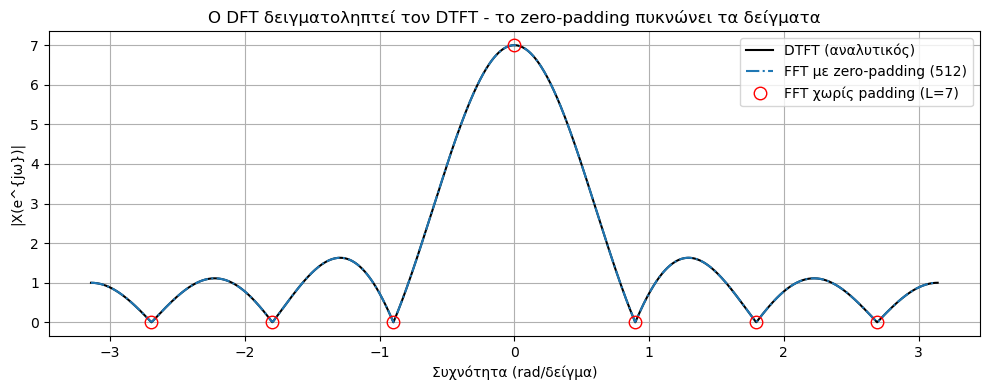

In [29]:
L = 7
n = np.arange(L)
x = np.ones(L)               # ορθογώνιος παλμός

# (α) αραιός FFT: μόνο L σημεία
X_coarse, w_coarse = myDTFTviaFFT(x, n, Nfft=L)

# (β) πυκνός FFT: μηδενική συμπλήρωση σε 512 σημεία
X_fine, w_fine = myDTFTviaFFT(x, n, Nfft=512)

# (γ) αναλυτικός DTFT (πυρήνας Dirichlet) σε πολύ πυκνό πλέγμα
w = np.linspace(-np.pi, np.pi, 2000)
with np.errstate(divide="ignore", invalid="ignore"):
    Xan = np.exp(-1j*w*(L-1)/2) * np.sin(w*L/2) / np.sin(w/2)
Xan[np.isclose(np.sin(w/2), 0.0)] = L   # όριο στο omega=0

plt.figure(figsize=(10, 4))
plt.plot(w, np.abs(Xan), color="black", label="DTFT (αναλυτικός)")
plt.plot(w_fine, np.abs(X_fine), "-.", ms=4, label="FFT με zero-padding (512)")
plt.plot(w_coarse, np.abs(X_coarse), "o", ms=9, mfc="none", color="red",
         label="FFT χωρίς padding (L=7)")
plt.grid(True); plt.legend()
plt.title("Ο DFT δειγματοληπτεί τον DTFT - το zero-padding πυκνώνει τα δείγματα")
plt.xlabel("Συχνότητα (rad/δείγμα)")
plt.ylabel("|X(e^{jω})|")
plt.tight_layout()
plt.show()

Οι κόκκινοι κύκλοι (αραιός FFT) είναι λίγοι αλλά $\textit{ακριβώς}$ πάνω στην καμπύλη· οι μπλε κουκκίδες (με μηδενική συμπλήρωση) γεμίζουν τα κενά και «ζωγραφίζουν» ολόκληρη την καμπύλη DTFT. Κανένα από τα δύο σετ δεν αλλάζει την $\textit{υποκείμενη}$ καμπύλη — απλώς την $\textit{δειγματοληπτούν}$ πιο αραιά ή πιο πυκνά. Αυτή είναι η ουσία της «προσομοίωσης του DTFT μέσω FFT».

---

### Ο αντίστροφος: IDTFT μέσω IFFT

Η ίδια αντιστοιχία ισχύει και προς τα πίσω. Ο αντίστροφος DTFT δίνεται από το ολοκλήρωμα
\begin{equation}
x[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n}\, d\omega.
\end{equation}
Αν δειγματοληπτήσουμε τον $X(e^{j\omega})$ στις $M$ συχνότητες $\omega_k = 2\pi k/M$ και προσεγγίσουμε το ολοκλήρωμα με άθροισμα Riemann ($\Delta\omega = 2\pi/M$), παίρνουμε
\begin{equation}
x[n] \approx \frac{1}{2\pi} \sum_{k=0}^{M-1} X[k]\, e^{j\frac{2\pi}{M} k n} \cdot \frac{2\pi}{M} = \frac{1}{M} \sum_{k=0}^{M-1} X[k]\, e^{j\frac{2\pi}{M} k n},
\end{equation}
που είναι $\textbf{ακριβώς}$ ο ορισμός του αντίστροφου DFT — δηλαδή αυτό που υπολογίζει η `numpy.fft.ifft`! Άρα ο αντίστροφος DTFT προσομοιώνεται με μία κλήση `ifft`. Η μόνη λεπτομέρεια είναι ότι, αν έχουμε δουλέψει με $\textit{κεντραρισμένο}$ πλέγμα (μετά από `fftshift`), πρέπει πρώτα να το επαναφέρουμε στη φυσική τάξη με `ifftshift` πριν καλέσουμε την `ifft`.

In [16]:
def myiDTFTviaFFT(X, w):
    """
    Αντίστροφος DTFT μέσω IFFT.

    Ορίσματα:
        X : 1D μιγαδικός πίνακας, δείγματα DTFT σε ΚΕΝΤΡΑΡΙΣΜΕΝΟ πλέγμα
            (όπως το επιστρέφει η myDTFTviaFFT), μήκους M
        w : το αντίστοιχο κεντραρισμένο πλέγμα συχνοτήτων (για συνέπεια API)

    Επιστρέφει:
        x : 1D μιγαδικός πίνακας μήκους M, το σήμα x[n] για n = 0..M-1
            (θεωρητικά πραγματικό, με αμελητέο φανταστικό μέρος)
    """
    X = np.asarray(X, dtype=np.complex128)
    Xnat = np.fft.ifftshift(X)   # επαναφορά στη φυσική τάξη [0, 2*pi)
    x = np.fft.ifft(Xnat)        # αντίστροφος DFT == άθροισμα Riemann του IDTFT
    return x

Ας ελέγξουμε ότι, ξεκινώντας από τον αναλυτικό DTFT του $(1/2)^n u[n]$, ανακτούμε το σήμα στο χρόνο.

Μέγιστο |φανταστικό μέρος|: 5.3153072879659425e-20


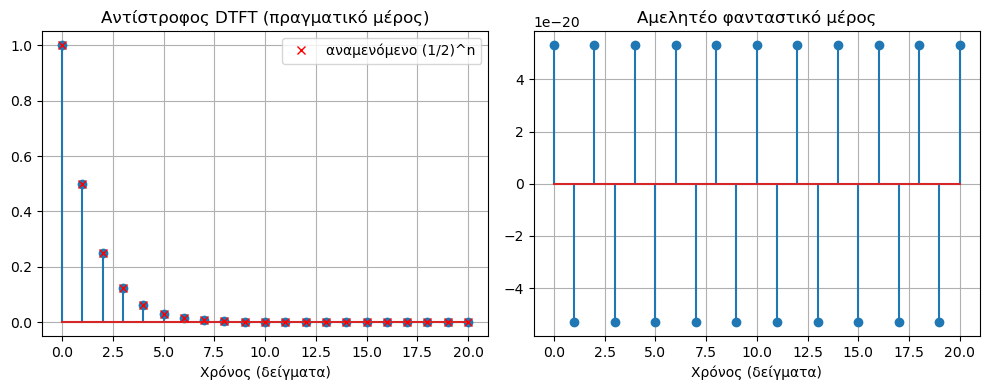

In [17]:
M = 512
w = np.fft.fftshift(2*np.pi*np.fft.fftfreq(M))   # κεντραρισμένο πλέγμα
X = 1.0 / (1 - 0.5*np.exp(-1j*w))                # αναλυτικός DTFT

x = myiDTFTviaFFT(X, w)
n = np.arange(21)                                # δείχνουμε τα πρώτα 21 δείγματα

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.stem(n, np.real(x[:21]))
plt.plot(n, (1/2)**n, "rx", label="αναμενόμενο (1/2)^n")
plt.grid(True); plt.legend()
plt.title("Αντίστροφος DTFT (πραγματικό μέρος)")
plt.xlabel("Χρόνος (δείγματα)")

plt.subplot(1, 2, 2)
plt.stem(n, np.imag(x[:21]))
plt.grid(True)
plt.title("Αμελητέο φανταστικό μέρος")
plt.xlabel("Χρόνος (δείγματα)")

plt.tight_layout()
print("Μέγιστο |φανταστικό μέρος|:", np.max(np.abs(np.imag(x))))

Το σήμα ανακτάται σωστά, με φανταστικό μέρος της τάξης του $10^{-20}$ (αριθμητικό σφάλμα).

---
---

## Ζητούμενα

**α.** Γράψτε κώδικα `Python` που υπολογίζει και τυπώνει το φάσμα πλάτους και φάσης των παρακάτω σημάτων $\textbf{με χρήση της συνάρτησης}$ `myDTFTviaFFT` (με κατάλληλη μηδενική συμπλήρωση για ομαλά διαγράμματα):

1. $x[n] = (-1/4)^n u[n]$
2. $x[n] = \delta[n-3]$
3. $x[n] = 2^n u[-n]$

Όπου είναι δυνατόν, υπερθέστε και τον αναλυτικό DTFT για επιβεβαίωση.

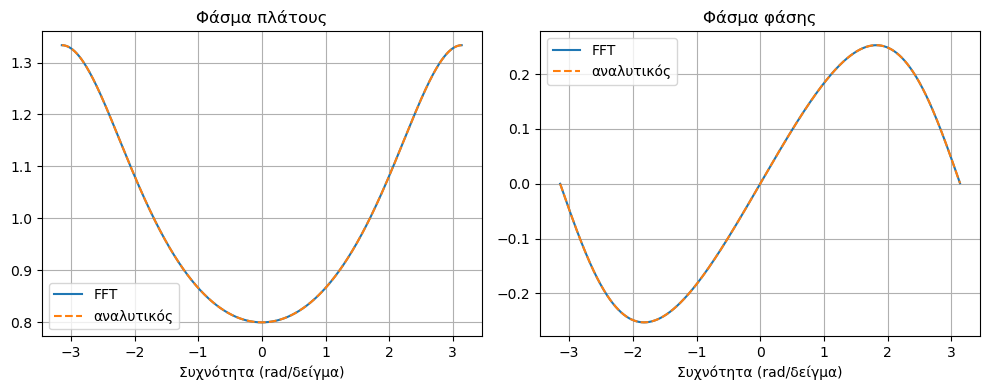

In [18]:
# 1.  x[n] = (-1/4)^n u[n]     ->     X = 1 / (1 + (1/4) e^{-jω})
N = 64
n = np.arange(N)
x = (-1/4)**n

X, w = myDTFTviaFFT(x, n, Nfft=2048)
Xan = 1.0 / (1 + 0.25*np.exp(-1j*w))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X), label="FFT"); plt.plot(w, np.abs(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend(); plt.title("Φάσμα πλάτους"); plt.xlabel("Συχνότητα (rad/δείγμα)")
plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X), label="FFT"); plt.plot(w, np.angle(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend(); plt.title("Φάσμα φάσης"); plt.xlabel("Συχνότητα (rad/δείγμα)")
plt.tight_layout()

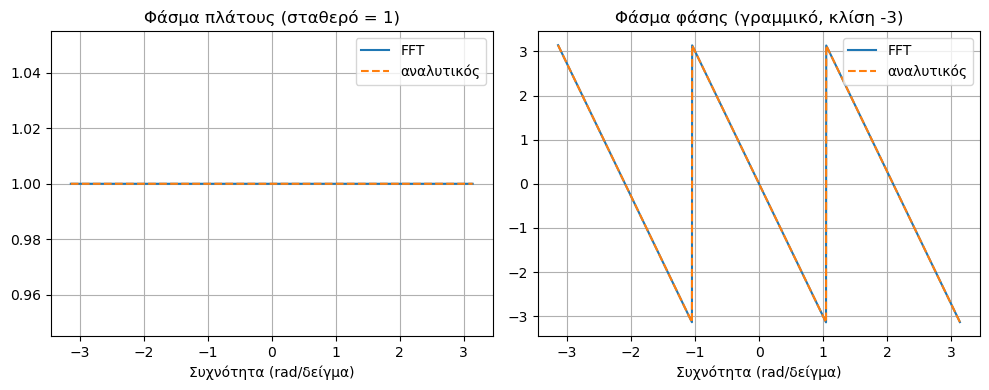

In [19]:
# 2.  x[n] = δ[n-3]     ->     X = e^{-j3ω}
N = 32
n = np.arange(N)
x = np.zeros(N); x[3] = 1.0

X, w = myDTFTviaFFT(x, n, Nfft=2048)
Xan = np.exp(-1j*3*w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X), label="FFT"); plt.plot(w, np.abs(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend(); plt.title("Φάσμα πλάτους (σταθερό = 1)"); plt.xlabel("Συχνότητα (rad/δείγμα)")
plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X), label="FFT"); plt.plot(w, np.angle(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend(); plt.title("Φάσμα φάσης (γραμμικό, κλίση -3)"); plt.xlabel("Συχνότητα (rad/δείγμα)")
plt.tight_layout()

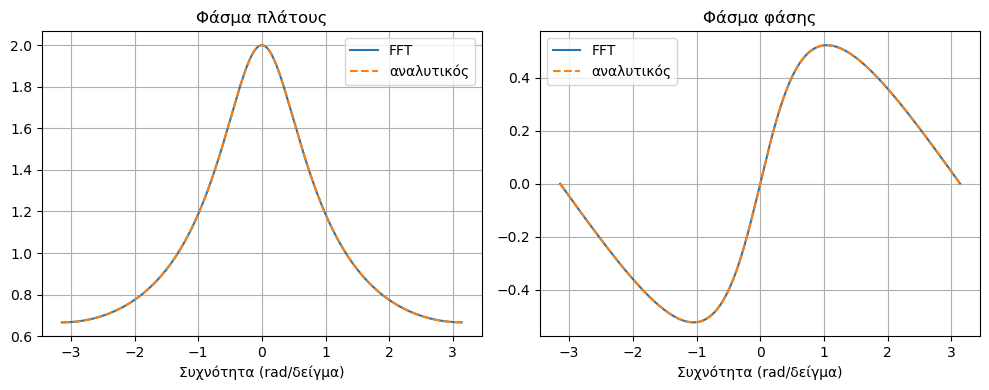

In [20]:
# 3.  x[n] = 2^n u[-n]  (αντι-αιτιατό)   ->   X = 1 / (1 - (1/2) e^{jω})
#     Αποθηκεύουμε τα δείγματα σε ΣΥΝΕΧΟΜΕΝΟ διάστημα χρόνου n = -N..0.
#     Η διόρθωση γραμμικής φάσης (n0 = -N) στη myDTFTviaFFT αναλαμβάνει τα υπόλοιπα.
N = 64
n = np.arange(-N, 1)          # -N .. 0
x = np.float_power(2.0, n)    # 2^n (σβήνει καθώς n -> -oo)

X, w = myDTFTviaFFT(x, n, Nfft=2048)
Xan = 1.0 / (1 - 0.5*np.exp(1j*w))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X), label="FFT"); plt.plot(w, np.abs(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend(); plt.title("Φάσμα πλάτους"); plt.xlabel("Συχνότητα (rad/δείγμα)")
plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X), label="FFT"); plt.plot(w, np.angle(Xan), "--", label="αναλυτικός")
plt.grid(True); plt.legend(); plt.title("Φάσμα φάσης"); plt.xlabel("Συχνότητα (rad/δείγμα)")
plt.tight_layout()

**β.** Έστω οι μετασχ. Fourier των παραπάνω σημάτων

1. $\displaystyle X(e^{j\omega}) = \frac{1}{1 + \frac{1}{4} e^{-j\omega}}$
2. $\displaystyle X(e^{j\omega}) = e^{-j3\omega}$

Γράψτε κώδικα `Python` που ανακτά το σήμα στο χρόνο (πραγματικό, με αμελητέο φανταστικό μέρος) $\textbf{με χρήση της συνάρτησης}$ `myiDTFTviaFFT`.

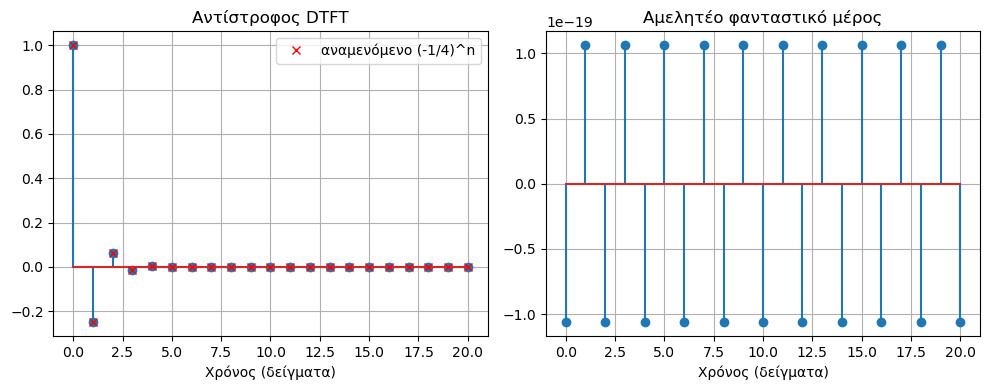

In [21]:
# 1.  X = 1 / (1 + (1/4) e^{-jω})   ->   x[n] = (-1/4)^n u[n]
M = 512
w = np.fft.fftshift(2*np.pi*np.fft.fftfreq(M))
X = 1.0 / (1 + 0.25*np.exp(-1j*w))

x = myiDTFTviaFFT(X, w)
n = np.arange(21)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(n, np.real(x[:21]))
plt.plot(n, (-1/4)**n, "rx", label="αναμενόμενο (-1/4)^n")
plt.grid(True); plt.legend(); plt.title("Αντίστροφος DTFT"); plt.xlabel("Χρόνος (δείγματα)")
plt.subplot(1, 2, 2)
plt.stem(n, np.imag(x[:21]))
plt.grid(True); plt.title("Αμελητέο φανταστικό μέρος"); plt.xlabel("Χρόνος (δείγματα)")
plt.tight_layout()

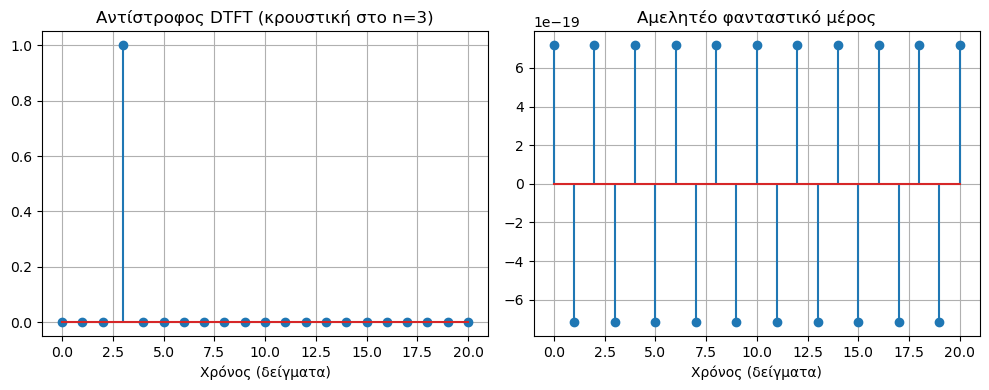

In [22]:
# 2.  X = e^{-j3ω}   ->   x[n] = δ[n-3]
M = 512
w = np.fft.fftshift(2*np.pi*np.fft.fftfreq(M))
X = np.exp(-1j*3*w)

x = myiDTFTviaFFT(X, w)
n = np.arange(21)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(n, np.real(x[:21]))
plt.grid(True); plt.title("Αντίστροφος DTFT (κρουστική στο n=3)"); plt.xlabel("Χρόνος (δείγματα)")
plt.subplot(1, 2, 2)
plt.stem(n, np.imag(x[:21]))
plt.grid(True); plt.title("Αμελητέο φανταστικό μέρος"); plt.xlabel("Χρόνος (δείγματα)")
plt.tight_layout()

### Παρατήρηση - όρια της μεθόδου (aliasing στο χρόνο)

Ο FFT ταυτίζεται με τον DTFT $\textbf{μόνο}$ όταν το σήμα χωρά πλήρως μέσα στα $N$ δείγματα! 

Για σήματα $\textit{άπειρης}$ διάρκειας (όπως το $(1/2)^n u[n]$) τα αποκόπτουμε — αν το $N$ είναι πολύ μικρό ώστε το σήμα να μην έχει σβήσει, εμφανίζεται $\textbf{χρονικό aliasing}$ (επικάλυψη περιόδων) και το φάσμα του FFT αποκλίνει ελαφρά από τον πραγματικό DTFT. 

Δοκιμάστε π.χ. να θέσετε `N = 4` στο πρώτο παράδειγμα ελέγχου και θα δείτε τη διαφορά. Ο κανόνας είναι απλός: $\textit{αποκόψτε το σήμα εκεί που έχει πρακτικά μηδενιστεί}$, και μετά κάντε όση μηδενική συμπλήρωση θέλετε για ομαλά διαγράμματα.

---
---